In [4]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


In [5]:
import sys
import os

sys.path.append(os.path.abspath("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main"))

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import euclidean_distances
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import networkx as nx
from sklearn.preprocessing import StandardScaler

In [5]:
old = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_04_claireNorm_PHASE1_mutants&WT_with_slopes.csv')
new = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_05_claireNorm_PHASE2_mutants&WT_with_slopes.csv')

/tmp/ipykernel_4054033/3503198913.py:2: DtypeWarning: Columns (463,464) have mixed types. Specify dtype option on import or set low_memory=False.
  new = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_05_claireNorm_PHASE2_mutants&WT_with_slopes.csv')


In [5]:
data = new

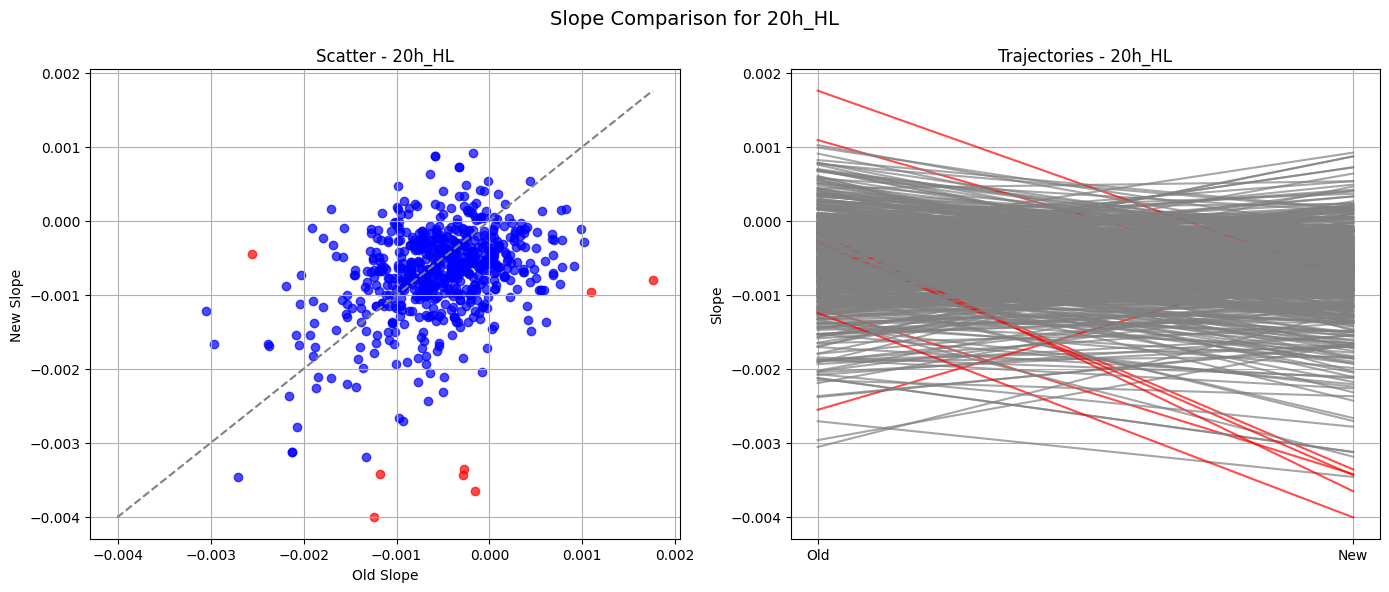

Number of changing genes:  8
     mutated_genes light_regime
160  Cre04.g213652       20h_HL
166  Cre04.g217935       20h_HL
188  Cre05.g236100       20h_HL
272  Cre07.g350250       20h_HL
423  Cre12.g489250       20h_HL
479  Cre13.g565150       20h_HL
530  Cre14.g613652       20h_HL
590  Cre16.g688350       20h_HL


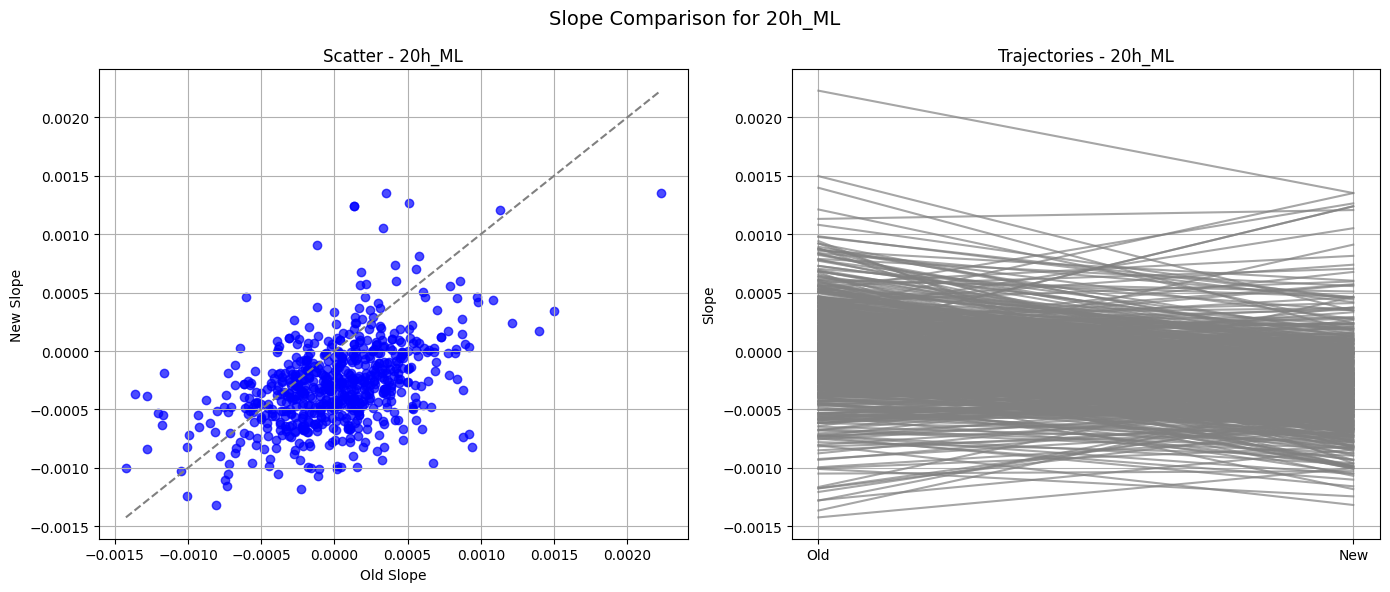

Number of changing genes:  0
Empty DataFrame
Columns: [mutated_genes, light_regime]
Index: []


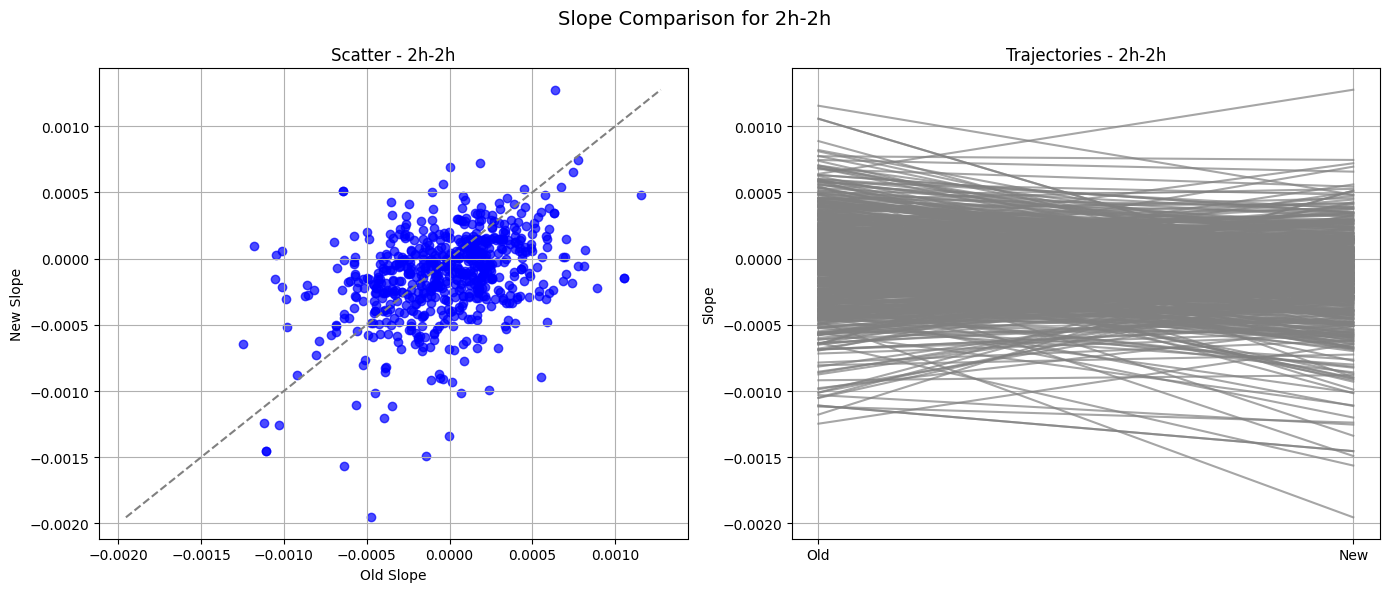

Number of changing genes:  0
Empty DataFrame
Columns: [mutated_genes, light_regime]
Index: []


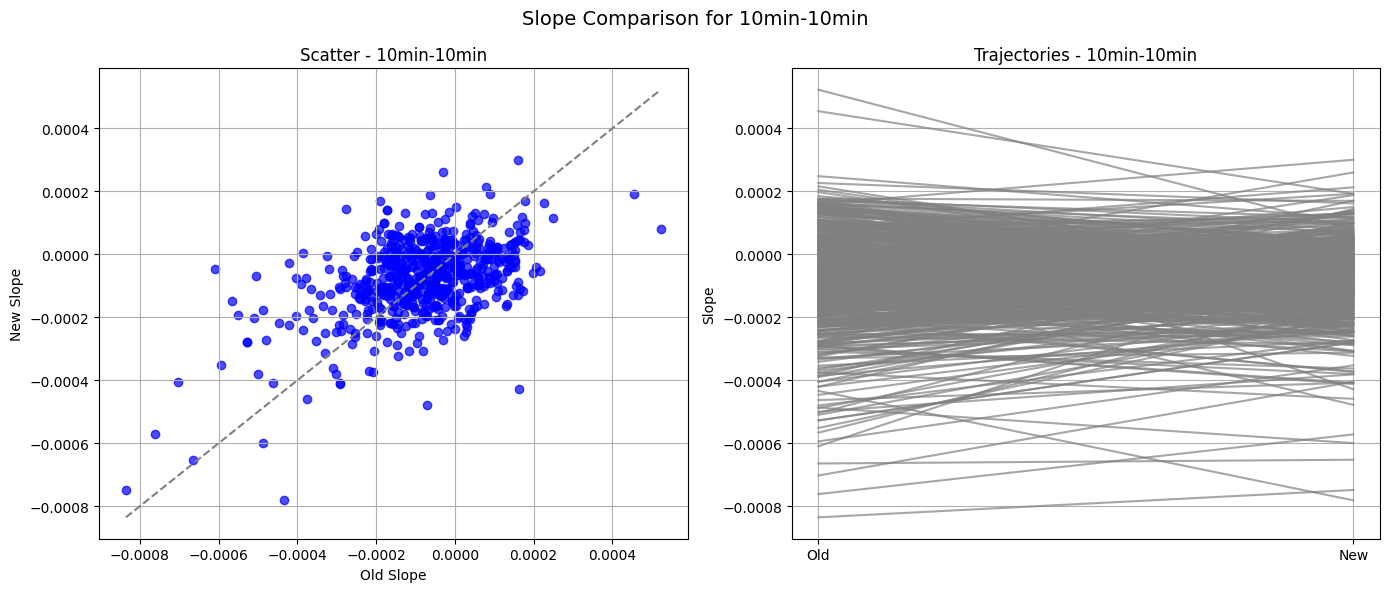

Number of changing genes:  0
Empty DataFrame
Columns: [mutated_genes, light_regime]
Index: []


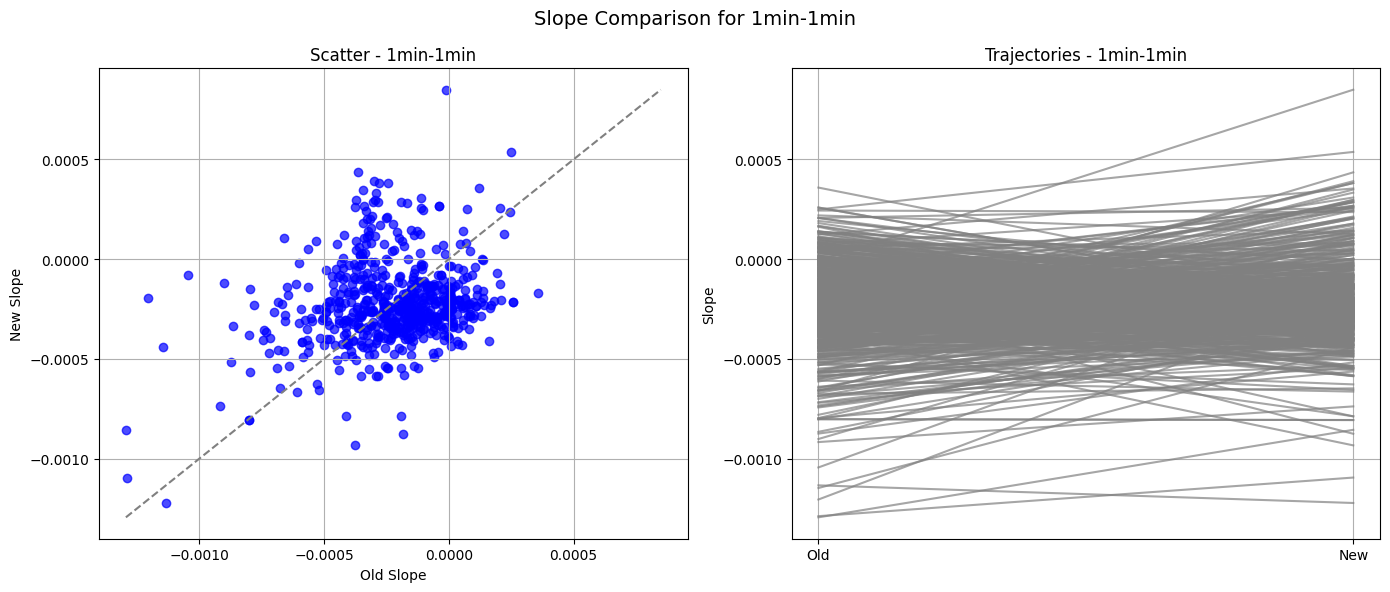

Number of changing genes:  0
Empty DataFrame
Columns: [mutated_genes, light_regime]
Index: []


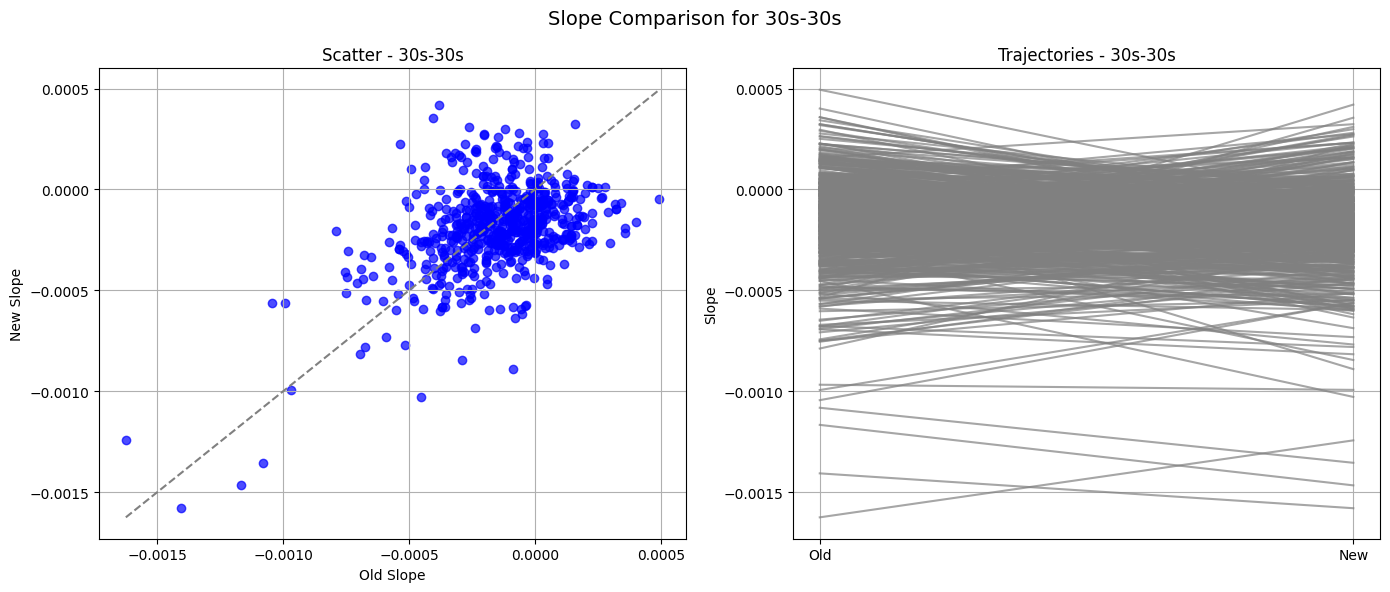

Number of changing genes:  0
Empty DataFrame
Columns: [mutated_genes, light_regime]
Index: []


In [9]:
threshold = 0.002

light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '1min-1min', '30s-30s']

for light in light_regimes:
    old_light = old[old['light_regime'] == light]
    new_light = new[new['light_regime'] == light]

    old_avg = old_light.groupby('mutated_genes')['y2_slope'].mean().reset_index(name='old_slope')
    new_avg = new_light.groupby('mutated_genes')['y2_slope'].mean().reset_index(name='new_slope')

    merged = pd.merge(old_avg, new_avg, on='mutated_genes', how='inner')
    merged['abs_diff'] = np.abs(merged['old_slope'] - merged['new_slope'])

    merged['significant'] =(merged['abs_diff'] > threshold)# &  (np.sign(merged['old_slope']) != np.sign(merged['new_slope'])) 

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for _, row in merged.iterrows():
        color = 'red' if row['significant'] else 'blue'
        axes[0].scatter(row['old_slope'], row['new_slope'], color=color, alpha=0.7)

    min_val = min(merged['old_slope'].min(), merged['new_slope'].min())
    max_val = max(merged['old_slope'].max(), merged['new_slope'].max())
    axes[0].plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--')
    axes[0].set_xlabel('Old Slope')
    axes[0].set_ylabel('New Slope')
    axes[0].set_title(f'Scatter - {light}')
    axes[0].grid(True)

    for _, row in merged.iterrows():
        color = 'red' if row['significant'] else 'gray'
        axes[1].plot(['Old', 'New'], [row['old_slope'], row['new_slope']], color=color, alpha=0.7)
    axes[1].set_title(f'Trajectories - {light}')
    axes[1].set_ylabel('Slope')
    axes[1].grid(True)

    plt.suptitle(f'Slope Comparison for {light}', fontsize=14)
    plt.tight_layout()
    plt.show()
    merged['light_regime'] = light 
    significant_mutants = merged[merged['significant']]
    sig = significant_mutants[['mutated_genes', 'light_regime']].drop_duplicates()
    print('Number of changing genes: ',len(sig))
    print(sig)



Intra-distance

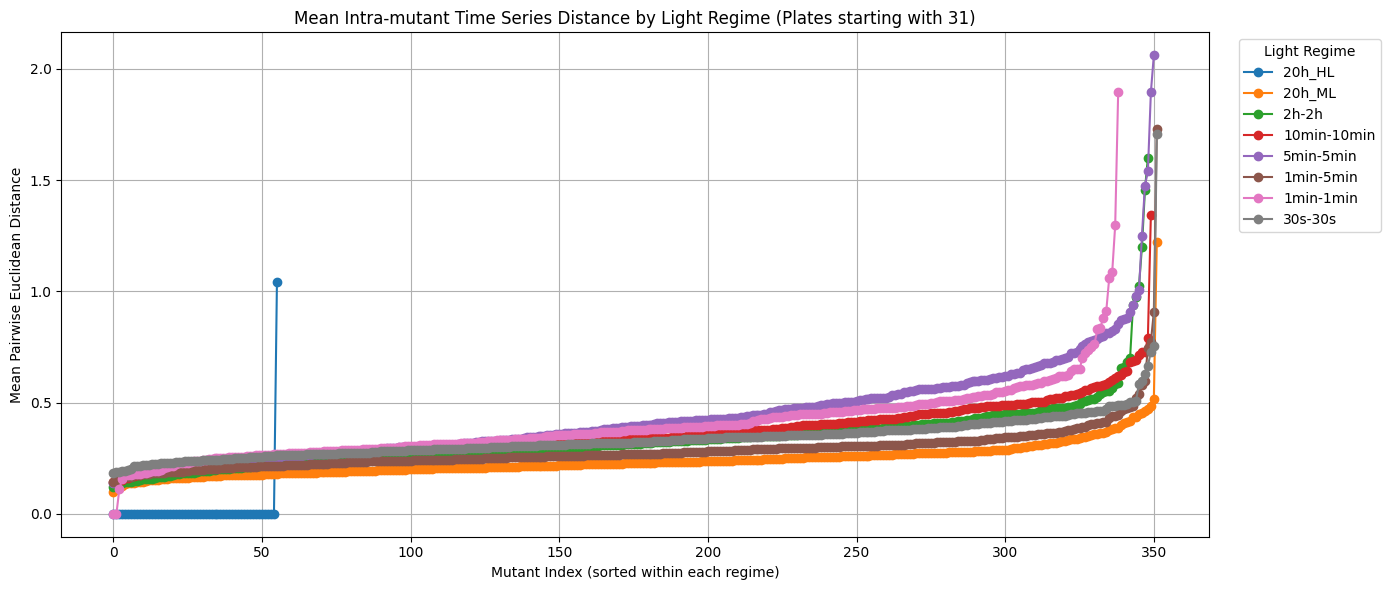

Total entries: 2501
               mean    max    std
light_regime                     
10min-10min   0.363  1.342  0.126
1min-1min     0.396  1.895  0.172
1min-5min     0.287  1.732  0.114
20h_HL        0.019  1.041  0.139
20h_ML        0.240  1.223  0.083
2h-2h         0.336  1.602  0.157
30s-30s       0.338  1.707  0.109
5min-5min     0.438  2.062  0.227

Top outliers in 20h_HL:
             mutant_ID  mean_distance  n_replicas
55                 WT   1.041154e+00           7
12  LMJ.RY0402.085477   7.450581e-09           3
37  LMJ.RY0402.174133   7.450581e-09           2
43  LMJ.RY0402.197381   7.450581e-09           2
32  LMJ.RY0402.158731   7.450581e-09           2

Top outliers in 20h_ML:
              mutant_ID  mean_distance  n_replicas
407                 WT       1.223173          21
139  LMJ.RY0402.092899       0.514721           2
93   LMJ.RY0402.061747       0.485852           3
172  LMJ.RY0402.116119       0.470322           3
326  LMJ.RY0402.206387       0.461761       

In [ ]:
plate_num = '31'
# Step 1: filter for plates starting with '30'
subset = data[data['plate'].astype(str).str.startswith(plate_num)]
# Step 2: define y2 columns and regime list
y2_cols = [col for col in data.columns if (col.startswith('y2_')) and ('std' not in col)]
light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-5min', '1min-1min', '30s-30s']

all_stats = []

# Step 3: compute pairwise distances per mutant × light regime
for light in light_regimes:
    sub_light = subset[subset['light_regime'] == light]

    for mutant_id, group in sub_light.groupby('mutant_ID'):
        # ts = group[y2_cols].dropna(thresh=39)  # keep rows with at least 75 non-NaN values
        # if ts.shape[0] < 2:
        
        # Inside your per-light_regime & mutant loop:
        ts = group[y2_cols]

        # Keep only columns that are present in at least X% of rows
        min_valid_ratio = 0.9
        valid_counts = ts.notna().mean()  # proportion of non-NaNs per column
        valid_cols = valid_counts[valid_counts >= min_valid_ratio].index
        ts = ts[valid_cols].dropna()

        if ts.shape[0] < 2 or ts.shape[1] == 0:
            continue  # Need at least 2 series to compute pairwise distances

        D = euclidean_distances(ts.values)
        triu_vals = D[np.triu_indices_from(D, k=1)]
        all_stats.append({
            'mutant_ID': mutant_id,
            'light_regime': light,
            'mean_distance': np.mean(triu_vals),
            'std_distance': np.std(triu_vals),
            'n_replicas': ts.shape[0]
        })

# Step 4: convert to DataFrame
df_stats = pd.DataFrame(all_stats)

# Step 5: plot one curve per light regime
plt.figure(figsize=(14, 6))

for light in light_regimes:
    df_light = df_stats[df_stats['light_regime'] == light].sort_values('mean_distance')
    plt.plot(
        range(len(df_light)),
        df_light['mean_distance'].values,
        marker='o',
        linestyle='-',
        label=light
    )

plt.title(f"Mean Intra-mutant Time Series Distance by Light Regime (Plates starting with {plate_num})")
plt.xlabel("Mutant Index (sorted within each regime)")
plt.ylabel("Mean Pairwise Euclidean Distance")
plt.legend(title="Light Regime", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

# Summary stats
print(f"Total entries: {len(df_stats)}")
print(df_stats.groupby('light_regime')['mean_distance'].agg(['mean', 'max', 'std']).round(3))

for light in light_regimes:
    outliers = df_stats[df_stats['light_regime'] == light].sort_values('mean_distance', ascending=False).head(5)
    print(f"\nTop outliers in {light}:\n", outliers[['mutant_ID', 'mean_distance', 'n_replicas']])


### Slopes of every mutant across 3 replicas

Standard deviation of the replicas of the same mutant

/tmp/ipykernel_4090807/505998519.py:1: DtypeWarning: Columns (462,463) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/phase2_05_RAWslopes.csv')


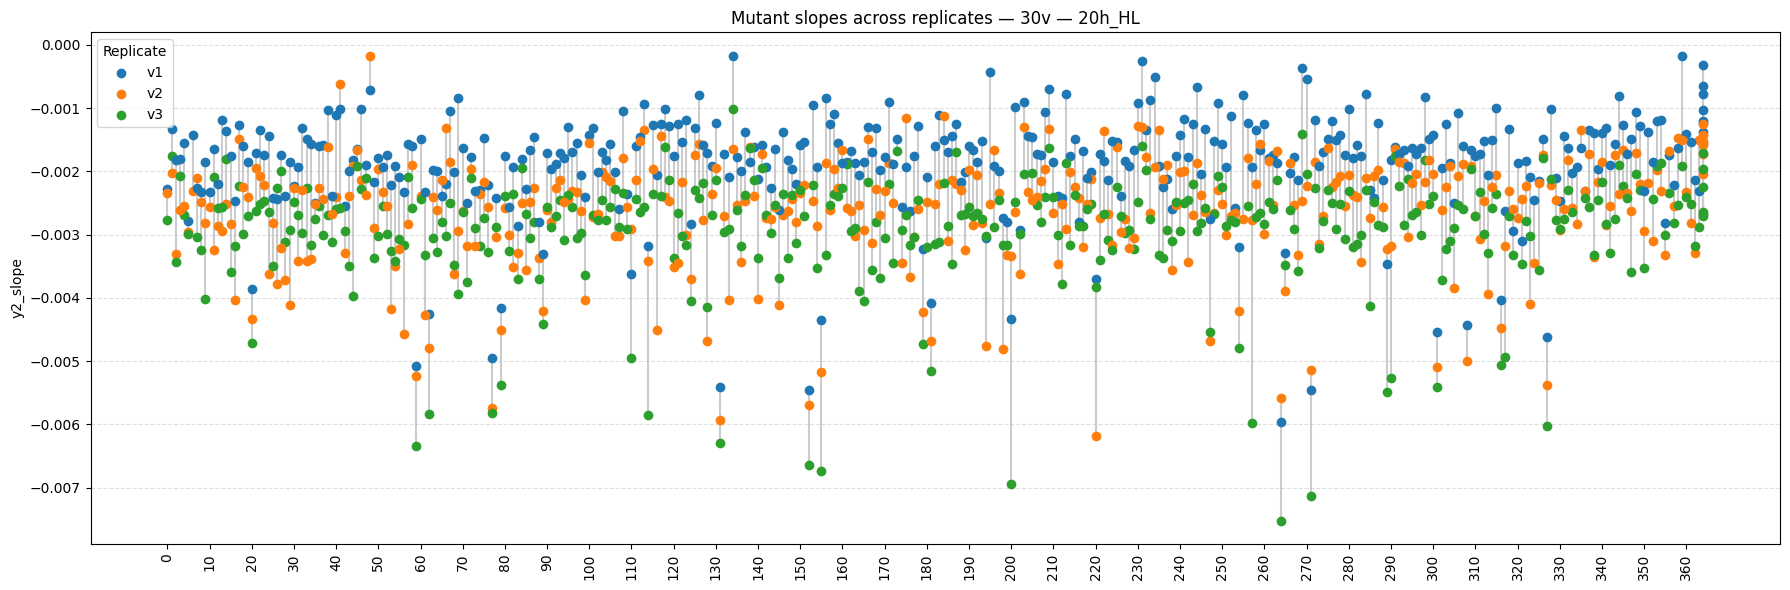

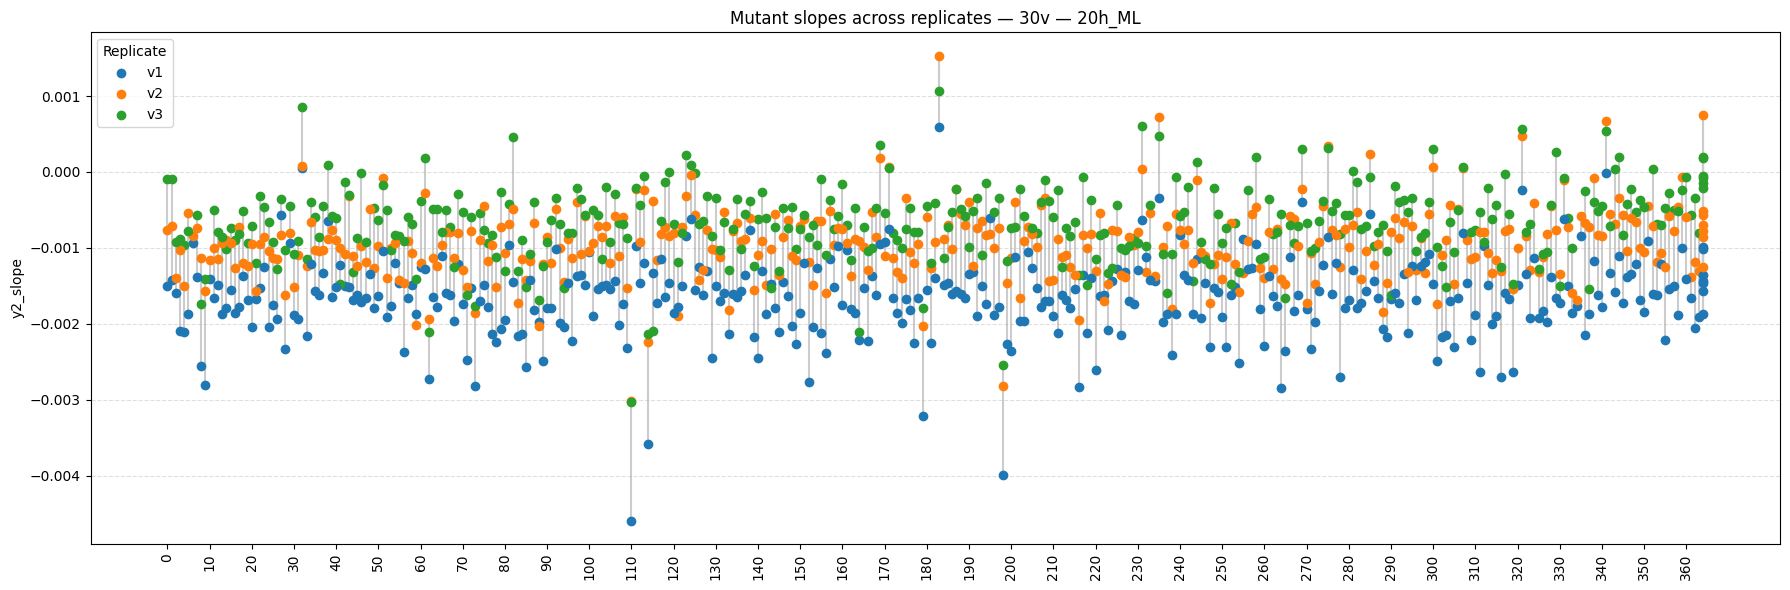

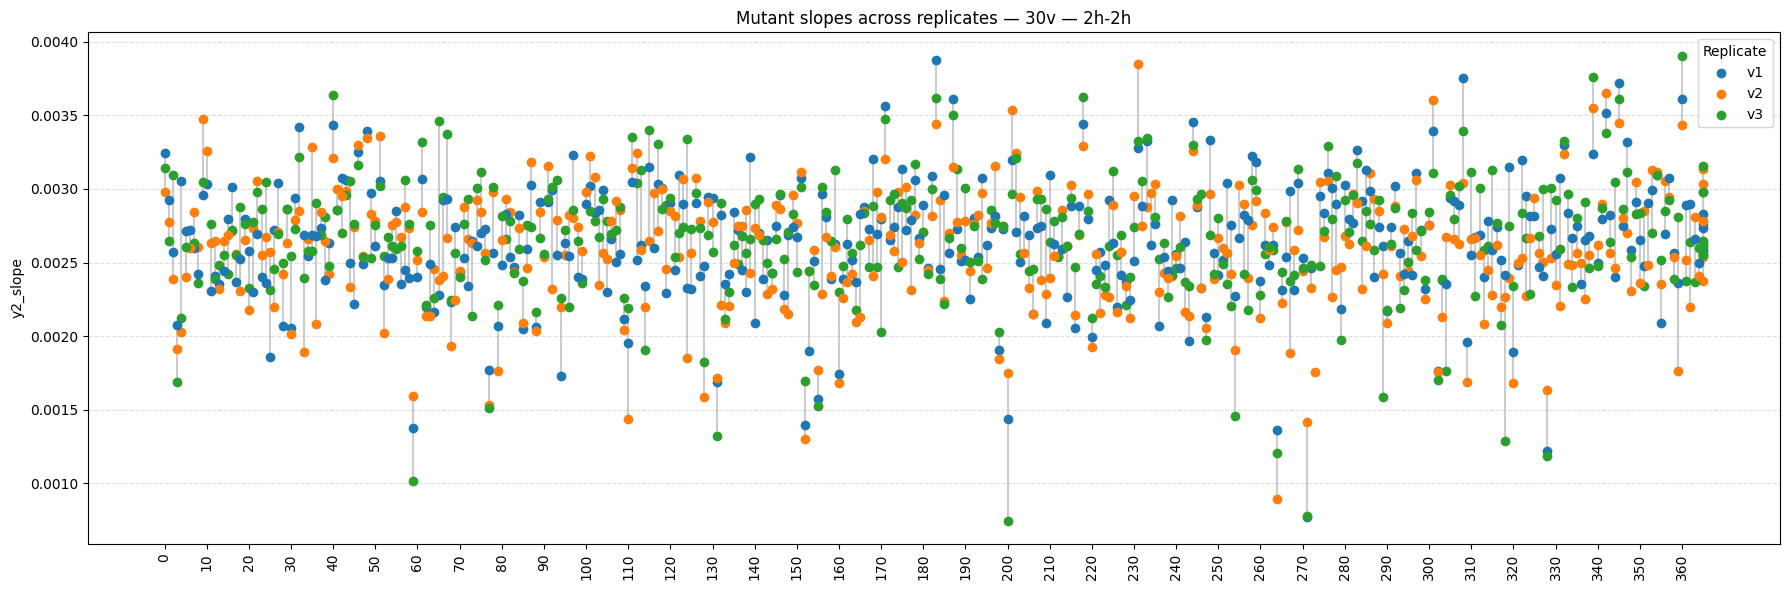

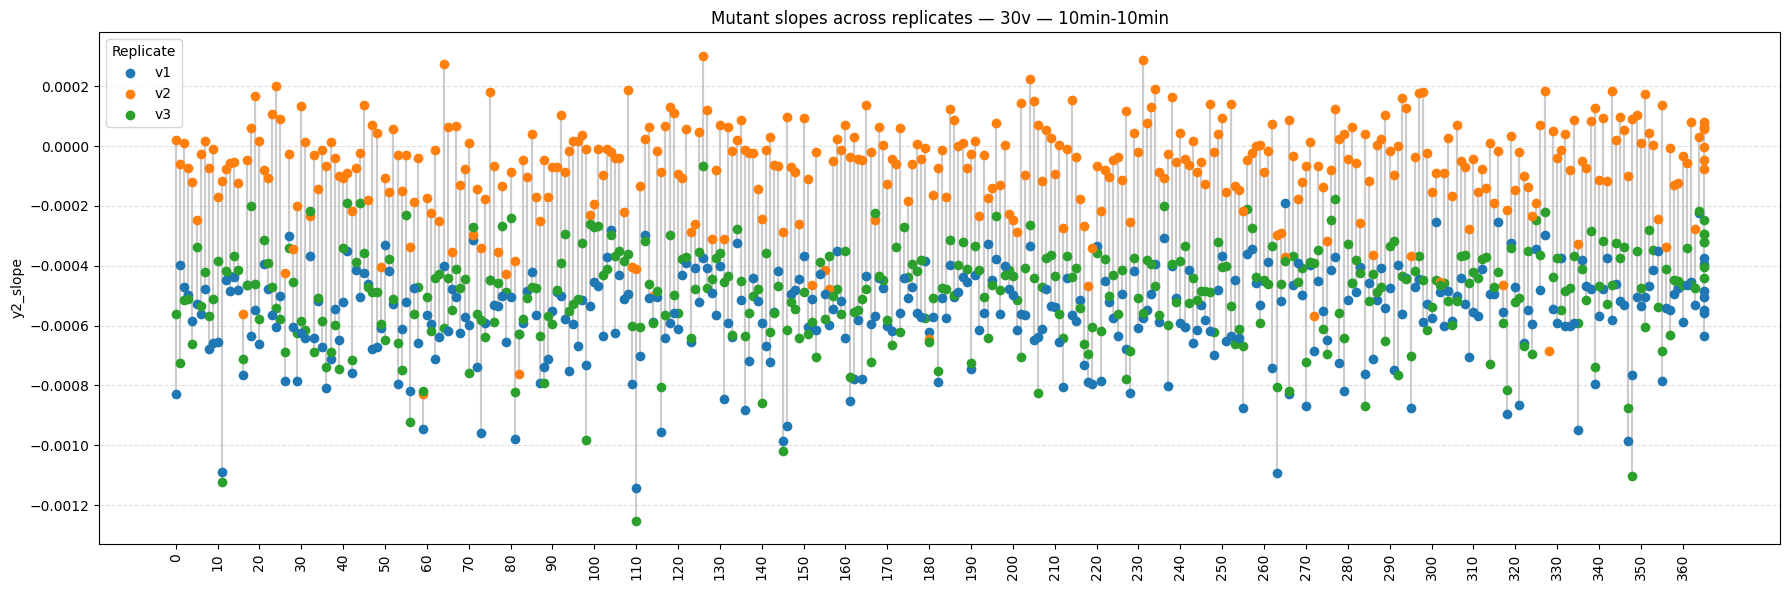

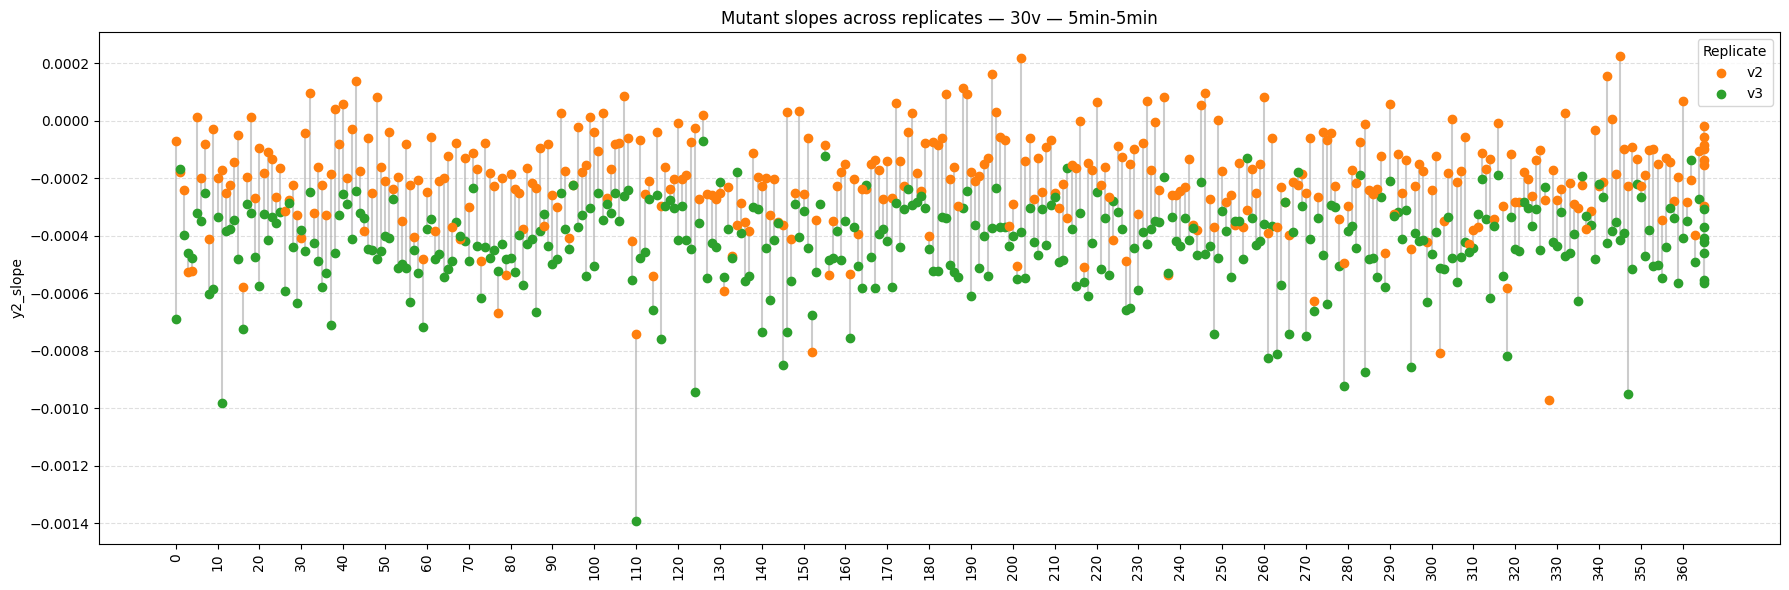

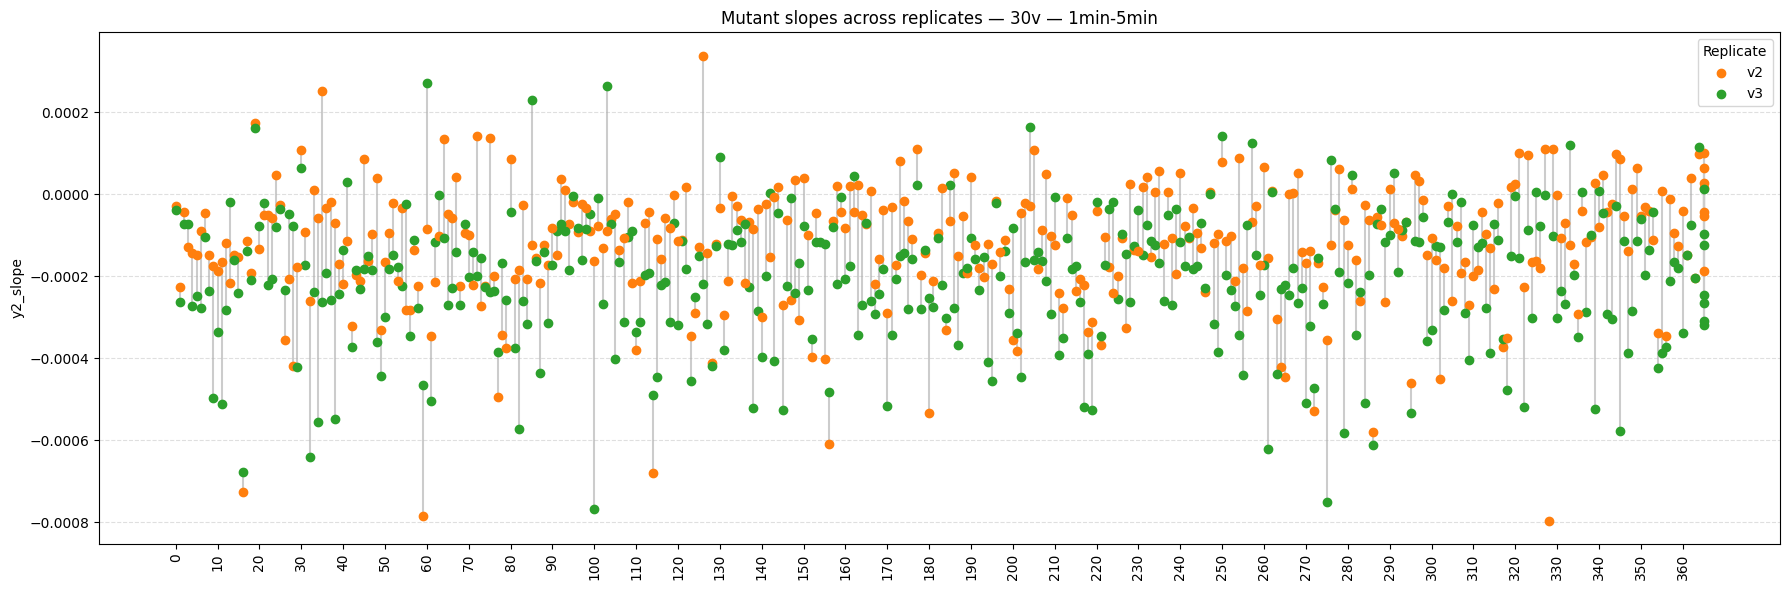

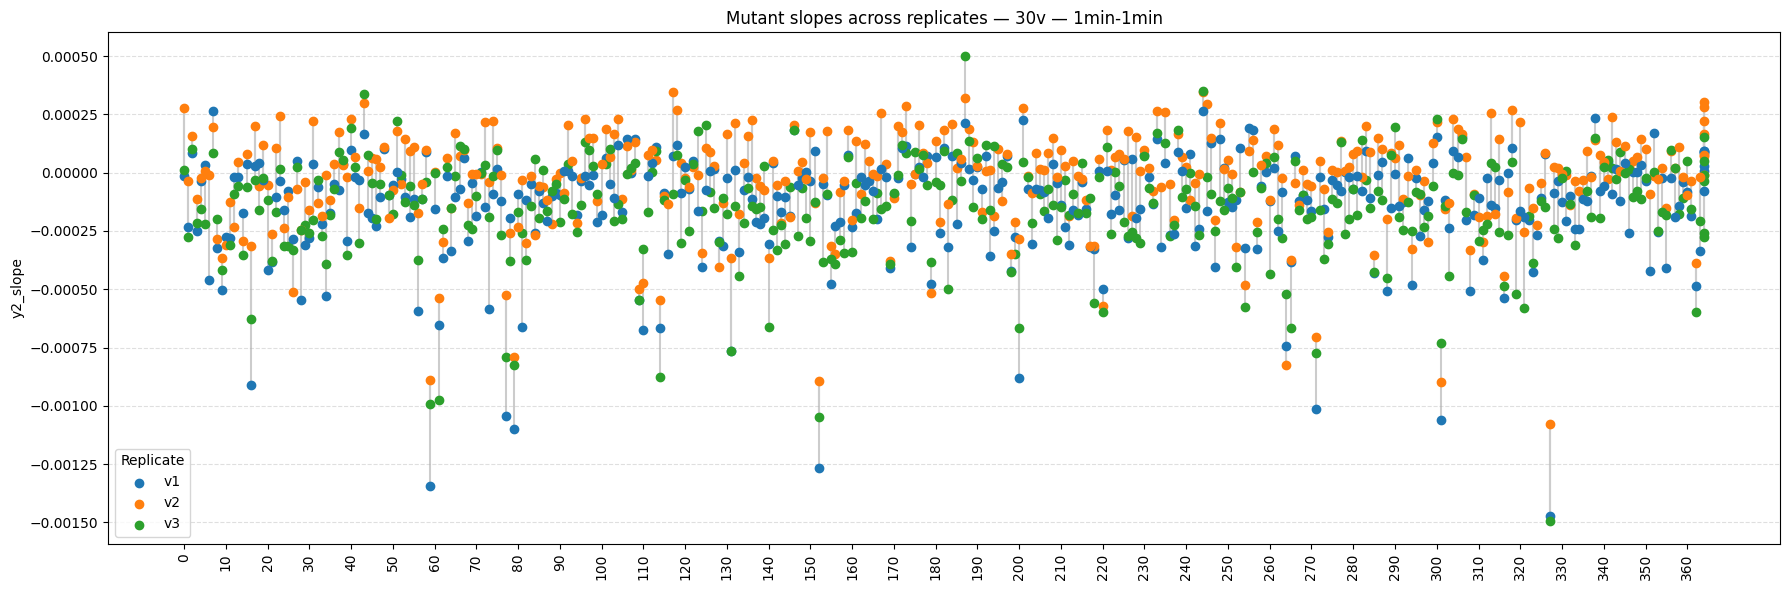

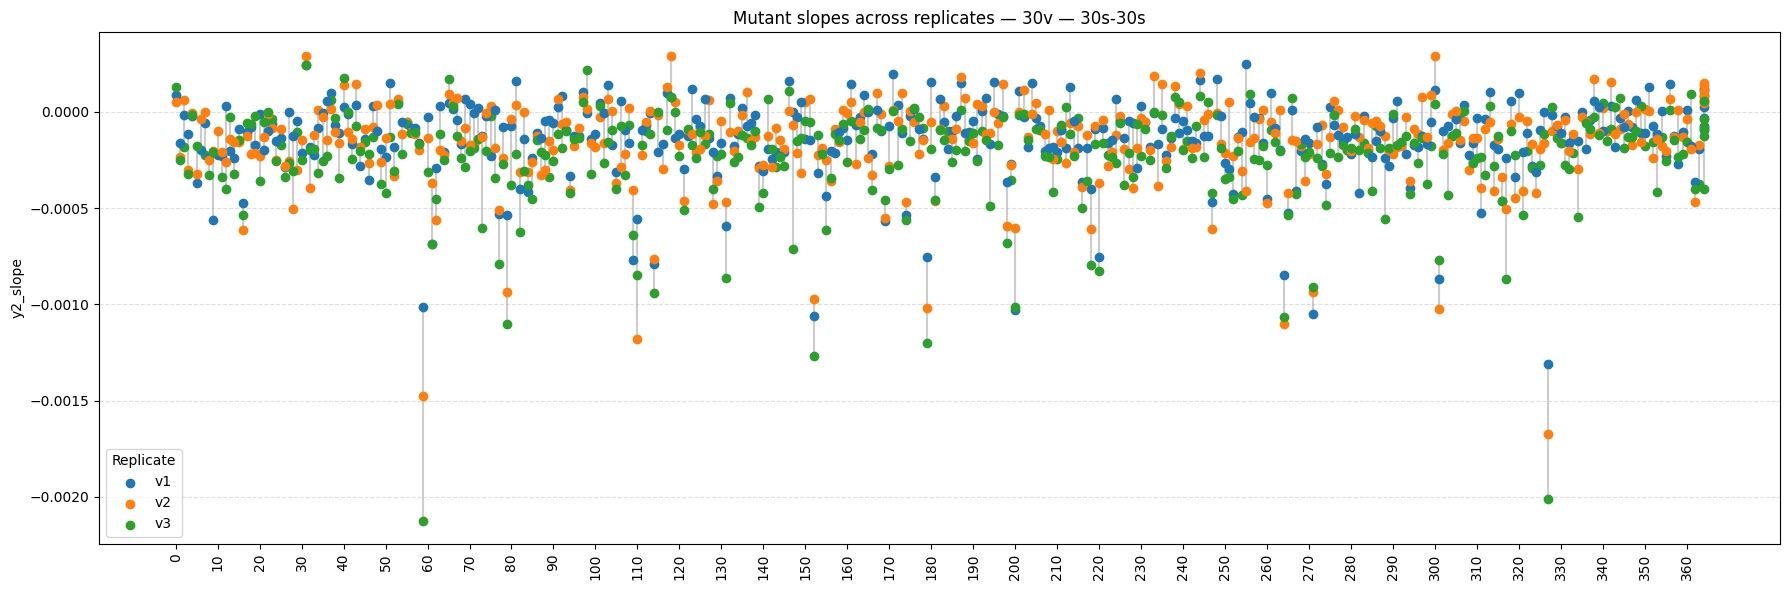

In [8]:
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/phase2_05_RAWslopes.csv')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

lights= ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-5min', '1min-1min', '30s-30s']
for light in lights:
    # ----------- Config ----------- #
    plate_group = '30v' 
    #light = '2h-2h'     
    palette = {'v1': 'tab:blue', 'v2': 'tab:orange', 'v3': 'tab:green'}
    # ----------------------------- #

    subset = data[
        (data['light_regime'] == light) &
        #(~data['mutant_ID'].isin(['WT', 'WT CLiP'])) &
        (data['plate'].astype(str).str.startswith(plate_group))
    ].copy()

    subset['rep'] = subset['plate'].astype(str).str.extract(r'v(\d)').astype(int)
    subset['rep'] = subset['rep'].map({1: 'v1', 2: 'v2', 3: 'v3'})
    subset['mutant_ID'] = subset['mutant_ID'].astype(str)

    mutant_order = sorted(subset['mutant_ID'].unique())
    subset['mutant_index'] = subset['mutant_ID'].apply(lambda x: mutant_order.index(x))

    plt.figure(figsize=(18, 6))

    for mutant in subset['mutant_ID'].unique():
        m_data = subset[subset['mutant_ID'] == mutant]
        x = mutant_order.index(mutant)
        y_vals = m_data.sort_values('rep')['y2_slope'].values
        reps = m_data.sort_values('rep')['rep'].values

        if len(y_vals) > 1:
            plt.plot([x]*len(y_vals), y_vals, color='gray', alpha=0.4, zorder=1)

        for rep, y in zip(reps, y_vals):
            plt.scatter(x, y, color=palette.get(rep, 'black'), label=rep if x == 0 else "", zorder=2)

    plt.xticks(range(0,len(mutant_order),10), range(0,len(mutant_order),10), rotation=90)
    plt.ylabel("y2_slope")
    plt.title(f"Mutant slopes across replicates — {plate_group} — {light}")
    plt.legend(title="Replicate")
    plt.grid(True, axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


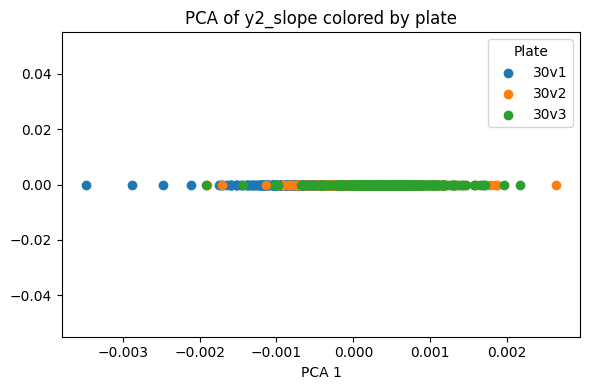

In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# Assume your DataFrame is called `data` and has columns: 'plate', 'y2_slope'
data = subset
# Drop missing values
df = data[['plate', 'y2_slope']].dropna()

# PCA requires 2D input — we simulate this by pivoting or repeating if needed
# If each 'y2_slope' is a single value per row, you can treat each row as a sample with 1 feature
X = df[['y2_slope']].values

# Run PCA (trivial in 1D, but done for compatibility)
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X)

# Plot
plt.figure(figsize=(6, 4))
for plate in df['plate'].unique():
    idx = df['plate'] == plate
    plt.scatter(X_pca[idx, 0], [0]*sum(idx), label=plate)

plt.xlabel('PCA 1')
plt.title('PCA of y2_slope colored by plate')
plt.legend(title='Plate')
plt.tight_layout()
plt.show()


In [4]:
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/phase2_05_RAWslopes.csv')
phase1_data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/phase1_05_RAWslopes.csv')

/tmp/ipykernel_2169713/174614440.py:1: DtypeWarning: Columns (1,366,367,368,369,462,463) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/phase2_05_RAWslopes.csv')


In [5]:
phase1 = phase1_data[phase1_data['mutant_ID']=='LMJ.RY0402.172376']


In [6]:
phase2 = data[data['mutant_ID']=='LMJ.RY0402.172376']


In [7]:
phase2

,Unnamed: 0,plate,measurement,start_date,light_regime,dark_threshold,light_threshold,num_frames,i,j,...,elapsed_hours_88,elapsed_hours_89,well_id,mutant_ID,feature,mutated_genes,num_mutations,fv_fm_end,ynpqend,y2_slope
21200,21200,32v1,M1,2024-08-04,1min-1min,15.868322,22.257633,180,7,12,...,20.092222,20.348056,H13,LMJ.RY0402.172376,NaN,Cre06.g278219,1.0,0.524400,0.015600,-0.000295
21633,21633,32v1,M2,2024-08-05,20h_HL,15.386411,19.596853,92,7,12,...,NaN,NaN,H13,LMJ.RY0402.172376,NaN,Cre06.g278219,1.0,0.492829,-0.015617,-0.002037
22066,22066,32v1,M3,2024-08-06,20h_ML,15.905910,20.674860,92,7,12,...,NaN,NaN,H13,LMJ.RY0402.172376,NaN,Cre06.g278219,1.0,0.549514,-0.047000,-0.001040
22478,22478,32v1,M8,2024-08-07,2h-2h,15.093113,21.415545,100,7,12,...,NaN,NaN,H13,LMJ.RY0402.172376,NaN,Cre06.g278219,1.0,0.575638,-0.067497,0.002569
22920,22920,32v1,M5,2024-08-08,30s-30s,15.507721,21.569485,180,7,12,...,20.136111,20.391944,H13,LMJ.RY0402.172376,NaN,Cre06.g278219,1.0,0.568655,-0.021385,-0.000430
23346,23346,32v1,M8,2024-08-11,5min-5min,15.786543,21.258650,180,7,12,...,20.030278,20.286111,H13,LMJ.RY0402.172376,NaN,Cre06.g278219,1.0,0.568856,-0.007920,-0.000282
25638,25638,32v2,M2,2024-08-21,20h_HL,15.213509,19.786570,92,11,15,...,NaN,NaN,L16,LMJ.RY0402.172376,NaN,Cre06.g278219,1.0,0.528916,-0.005240,-0.001692
26071,26071,32v2,M3,2024-08-22,20h_ML,16.117708,21.287655,92,11,15,...,NaN,NaN,L16,LMJ.RY0402.172376,NaN,Cre06.g278219,1.0,0.575715,-0.034788,-0.001458
26504,26504,32v2,M4,2024-08-23,2h-2h,15.573068,22.313528,100,11,15,...,NaN,NaN,L16,LMJ.RY0402.172376,NaN,Cre06.g278219,1.0,0.588489,-0.081373,0.002671
26937,26937,32v2,M5,2024-08-24,30s-30s,15.259409,21.184788,180,11,15,...,20.138611,20.394444,L16,LMJ.RY0402.172376,NaN,Cre06.g278219,1.0,0.554498,0.002219,-0.000076


In [8]:
phase2.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/LMJ.RY0402.172376.csv', index=False)

In [13]:
mut=data[data['mutant_ID']=='LMJ.RY0402.200883']

In [14]:
mut

,Unnamed: 0,plate,measurement,start_date,light_regime,dark_threshold,light_threshold,num_frames,i,j,...,elapsed_hours_88,elapsed_hours_89,well_id,mutant_ID,feature,mutated_genes,num_mutations,fv_fm_end,ynpqend,y2_slope
17847,17847,31v1,M1,2024-07-27,1min-1min,15.812491,22.504938,180,5,18,...,20.065833,20.321667,F19,LMJ.RY0402.200883,intergenic,Cre09.g404503,2.0,0.537964,-0.018466,-0.000144
17848,17848,31v1,M1,2024-07-27,1min-1min,15.812491,22.504938,180,5,18,...,20.065833,20.321667,F19,LMJ.RY0402.200883,intergenic,Cre09.g404500,2.0,0.537964,-0.018466,-0.000144
17849,17849,31v1,M1,2024-07-27,1min-1min,15.812491,22.504938,180,5,18,...,20.065833,20.321667,F19,LMJ.RY0402.200883,intergenic,Cre09.g404503,2.0,0.537964,-0.018466,-0.000144
19082,19082,31v1,M2,2024-07-28,20h_HL,16.247263,20.847513,92,5,18,...,NaN,NaN,F19,LMJ.RY0402.200883,intergenic,Cre09.g404503,2.0,0.517530,-0.011119,-0.001453
19083,19083,31v1,M2,2024-07-28,20h_HL,16.247263,20.847513,92,5,18,...,NaN,NaN,F19,LMJ.RY0402.200883,intergenic,Cre09.g404500,2.0,0.517530,-0.011119,-0.001453
19084,19084,31v1,M2,2024-07-28,20h_HL,16.247263,20.847513,92,5,18,...,NaN,NaN,F19,LMJ.RY0402.200883,intergenic,Cre09.g404503,2.0,0.517530,-0.011119,-0.001453
19494,19494,31v1,M3,2024-07-29,20h_ML,15.940679,21.125126,92,5,18,...,NaN,NaN,F19,LMJ.RY0402.200883,intergenic,Cre09.g404503,2.0,0.586271,-0.032141,-0.000669
19495,19495,31v1,M3,2024-07-29,20h_ML,15.940679,21.125126,92,5,18,...,NaN,NaN,F19,LMJ.RY0402.200883,intergenic,Cre09.g404500,2.0,0.586271,-0.032141,-0.000669
19496,19496,31v1,M3,2024-07-29,20h_ML,15.940679,21.125126,92,5,18,...,NaN,NaN,F19,LMJ.RY0402.200883,intergenic,Cre09.g404503,2.0,0.586271,-0.032141,-0.000669
19931,19931,31v1,M5,2024-07-31,2h-2h,14.790424,21.503479,100,5,18,...,NaN,NaN,F19,LMJ.RY0402.200883,intergenic,Cre09.g404503,2.0,0.581899,-0.077296,0.002789


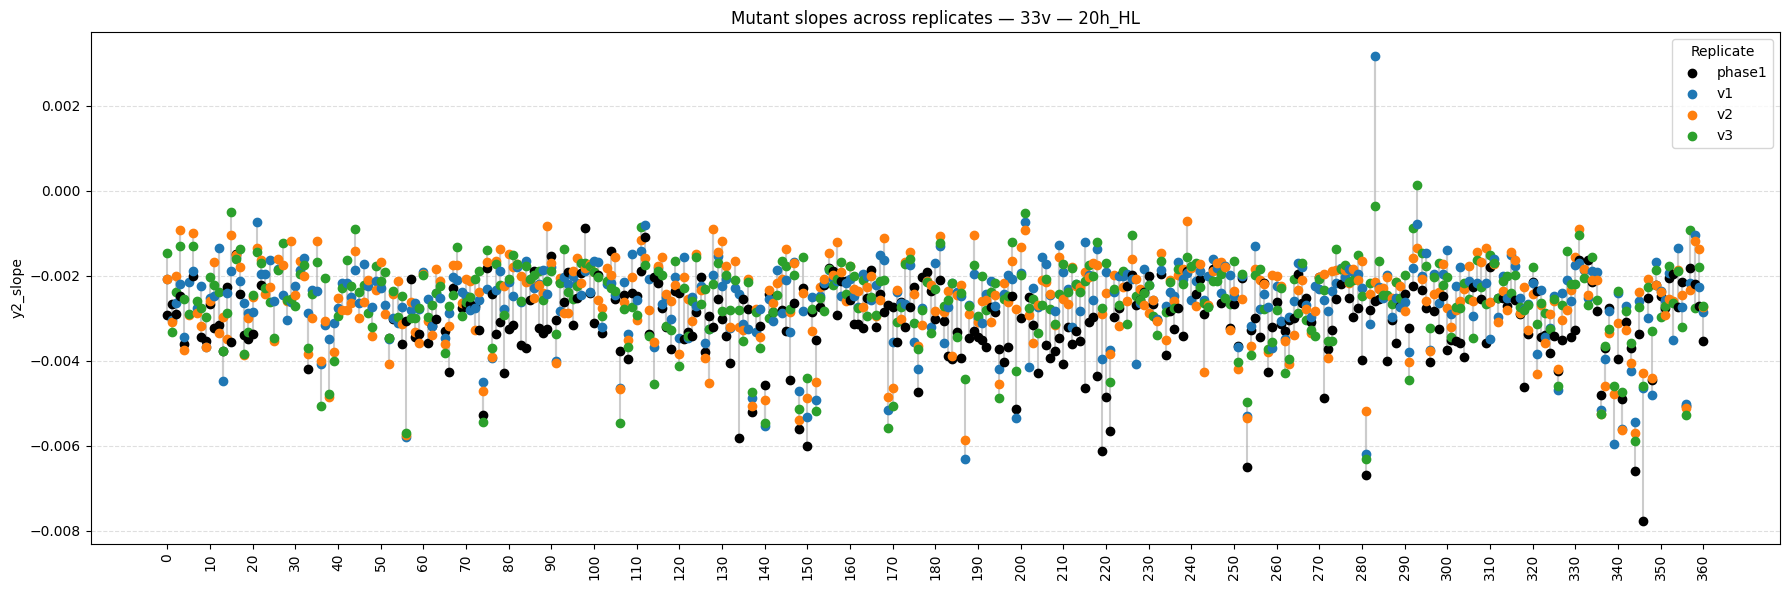

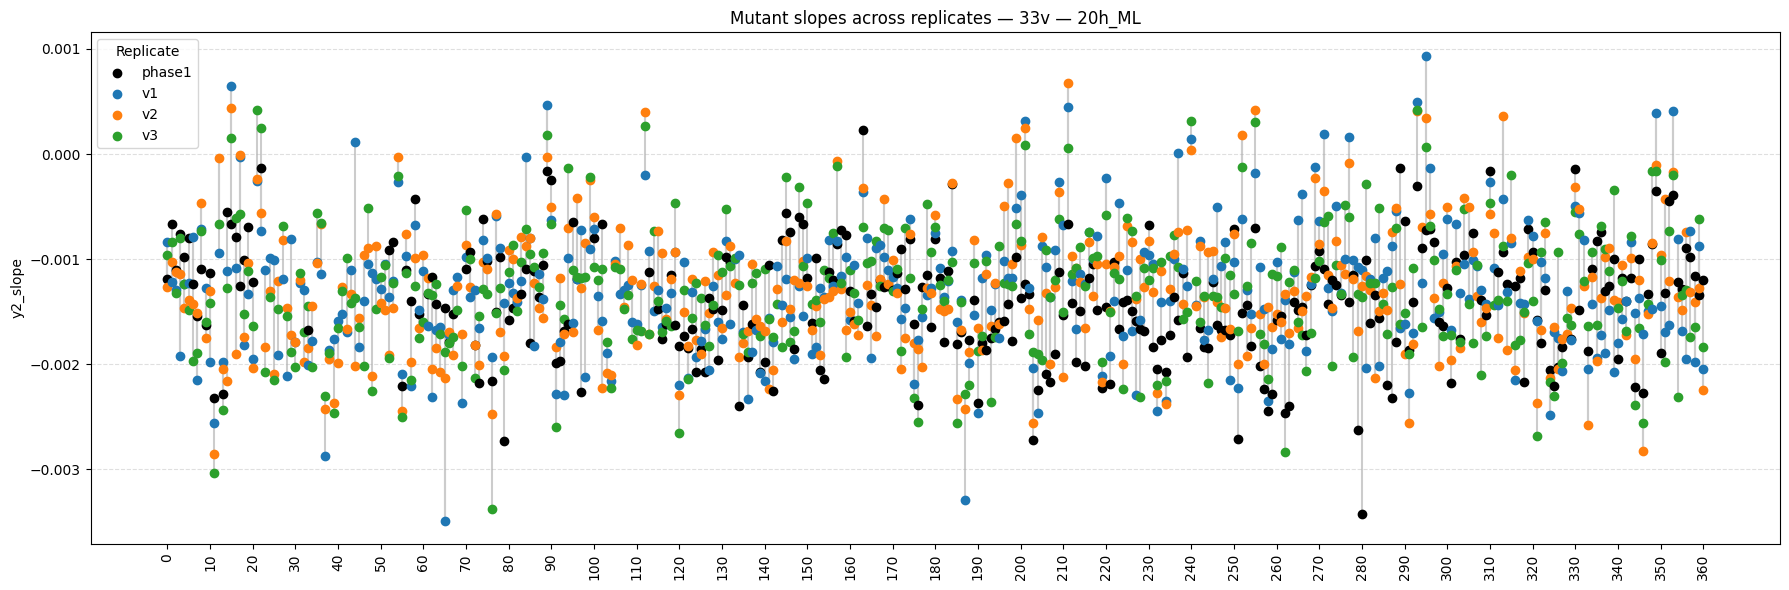

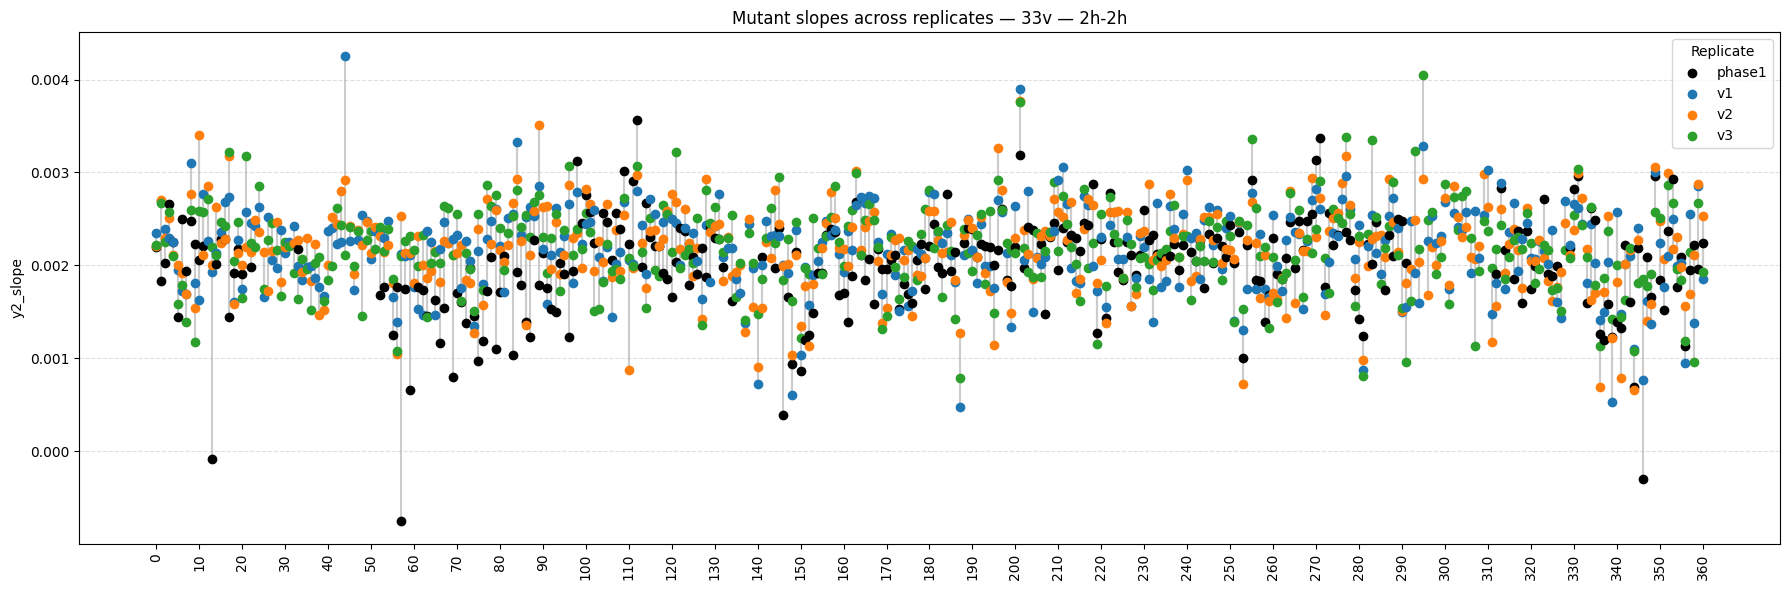

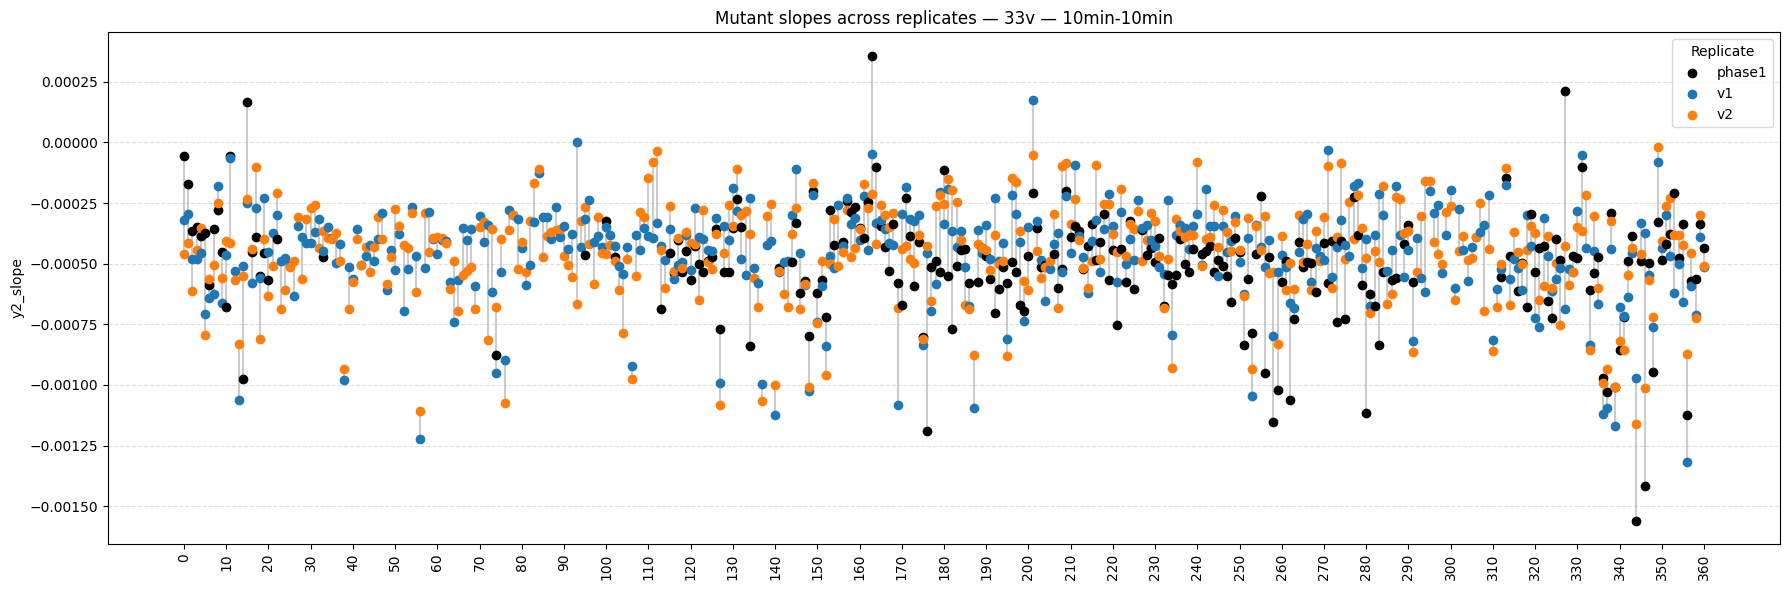

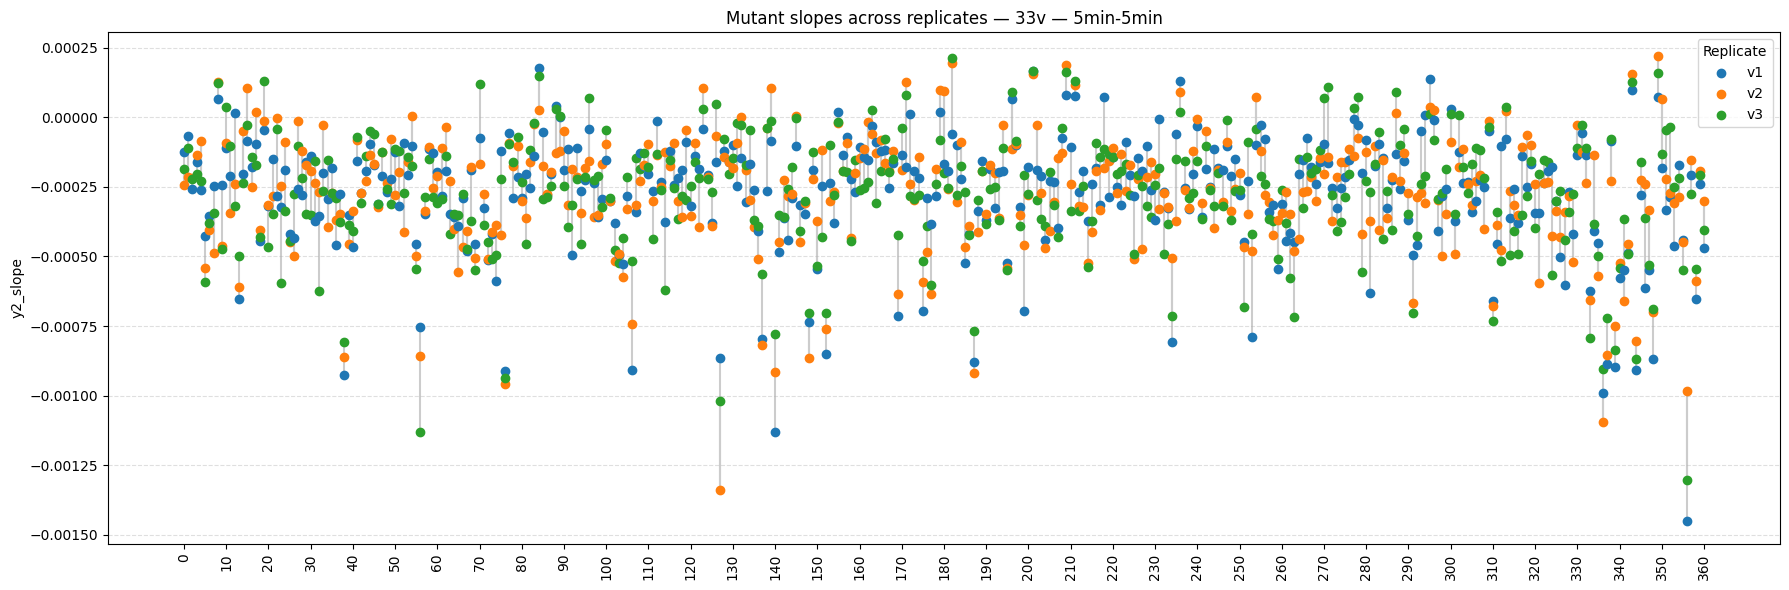

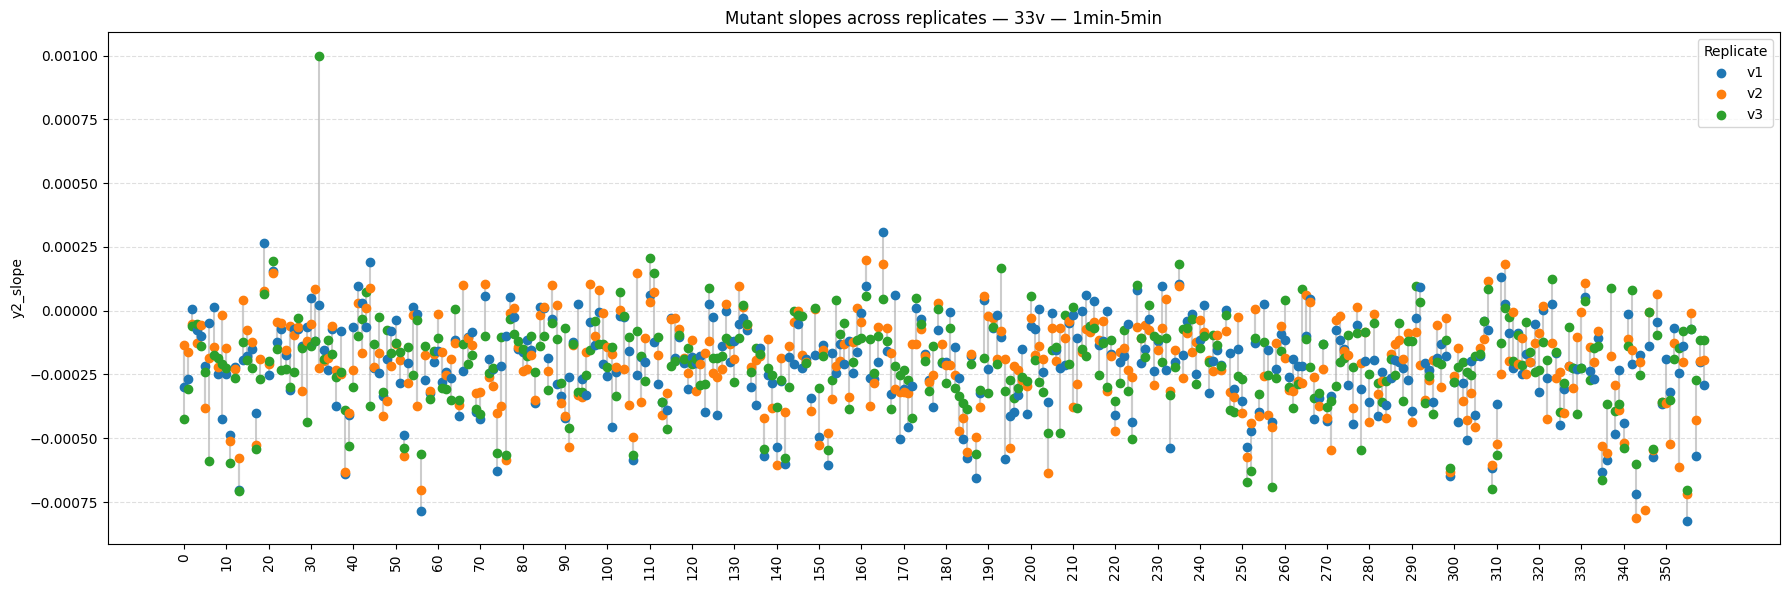

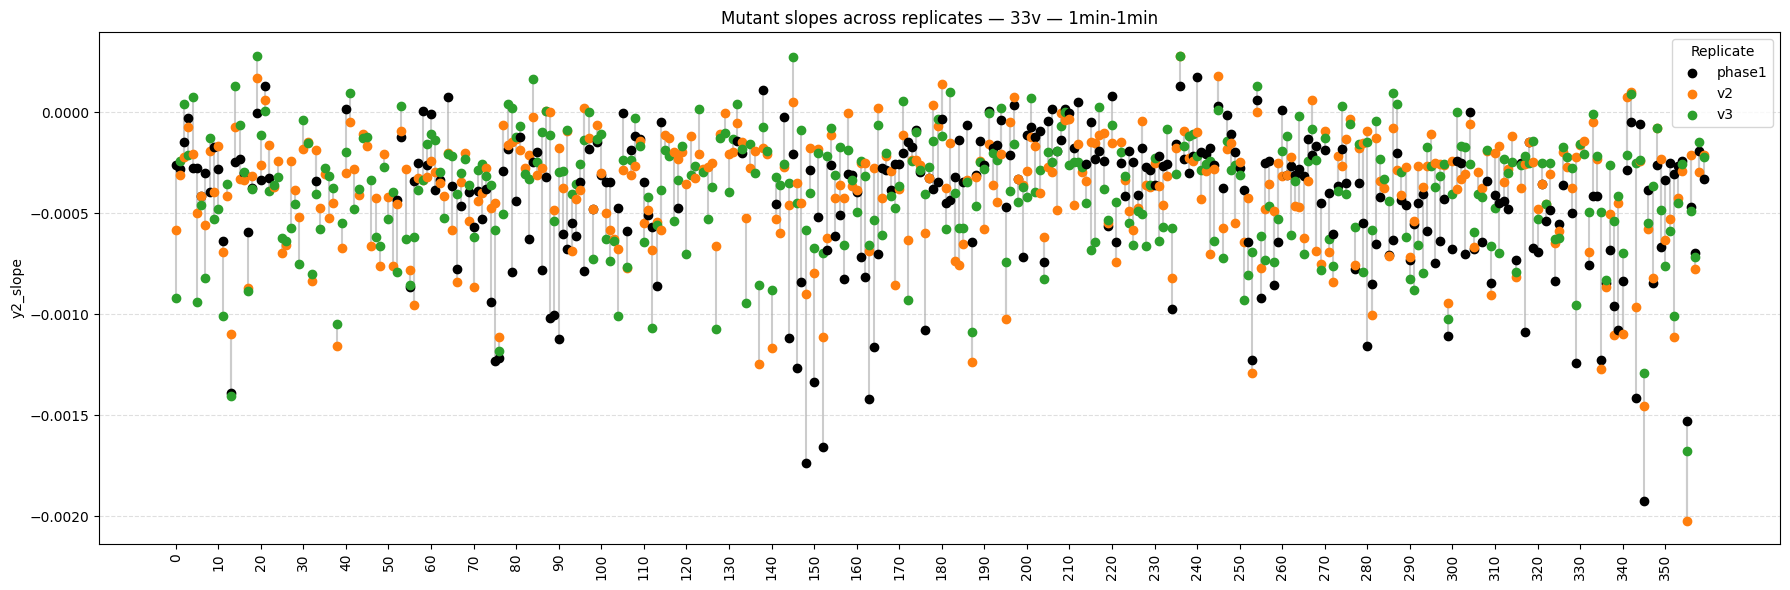

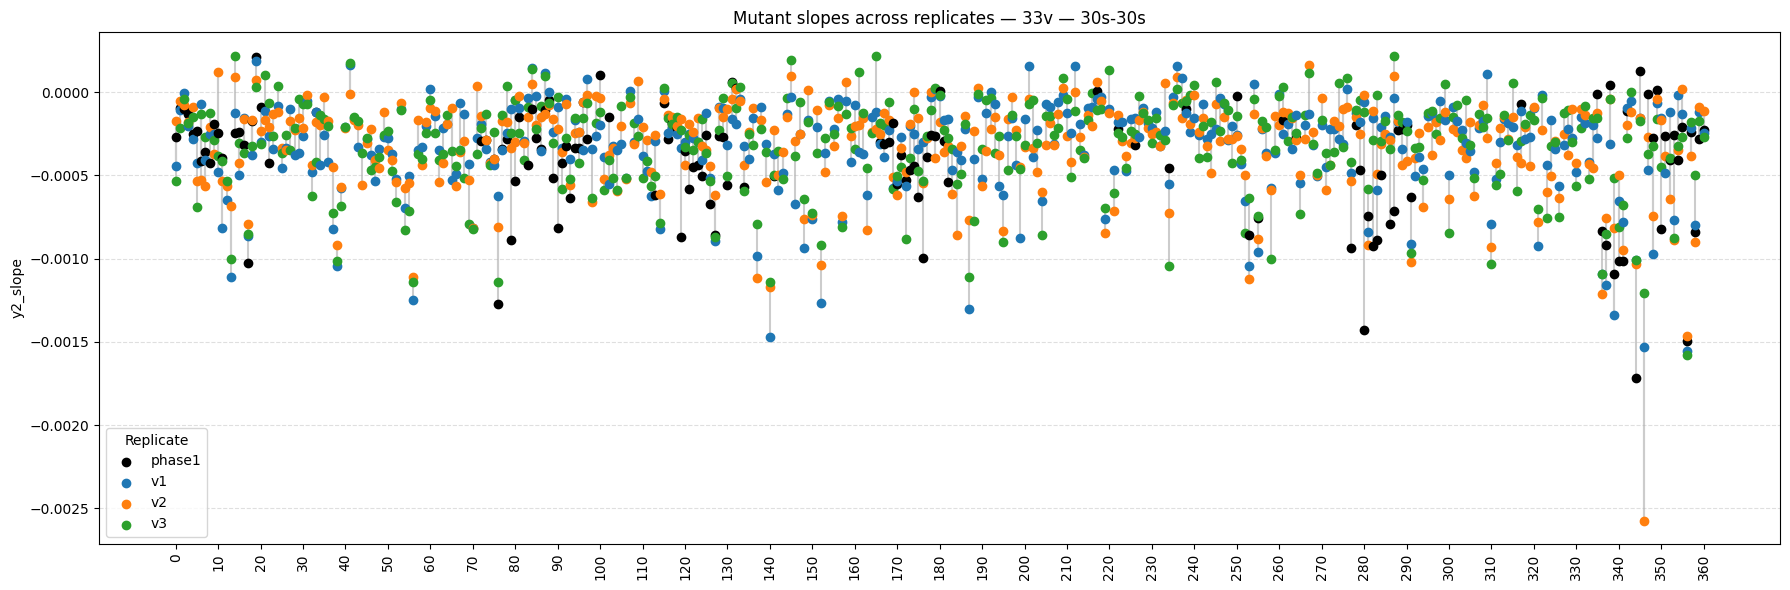

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/combat_all_lights/Phase2_combined_combat_data.csv')
phase1_data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/phase1_05_RAWslopes.csv')  # <- UPDATE path

lights = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-5min', '1min-1min', '30s-30s']
palette = {'v1': 'tab:blue', 'v2': 'tab:orange', 'v3': 'tab:green', 'phase1': 'black'}

for light in lights:
    plate_group = '33v'

    subset = data[
        (data['light_regime'] == light) &
        (~data['mutant_ID'].isin(['WT', 'WT CLiP'])) &
        (data['plate'].astype(str).str.startswith(plate_group))
    ].copy()

    subset['rep'] = subset['plate'].astype(str).str.extract(r'v(\d)').astype(int)
    subset['rep'] = subset['rep'].map({1: 'v1', 2: 'v2', 3: 'v3'})
    subset['mutant_ID'] = subset['mutant_ID'].astype(str)

    # Add phase1 data
    old_subset = phase1_data[
        (phase1_data['light_regime'] == light) &
        (~data['mutant_ID'].isin(['WT', 'WT CLiP'])) &
        (phase1_data['mutant_ID'].isin(subset['mutant_ID'].unique()))
    ][['mutant_ID', 'y2_slope']].copy()
    old_subset['rep'] = 'phase1'

    subset = pd.concat([subset[['mutant_ID', 'y2_slope', 'rep']], old_subset], ignore_index=True)
    subset['mutant_ID'] = subset['mutant_ID'].astype(str)

    mutant_order = sorted(subset['mutant_ID'].unique())
    subset['mutant_index'] = subset['mutant_ID'].apply(lambda x: mutant_order.index(x))

    plt.figure(figsize=(18, 6))

    for mutant in subset['mutant_ID'].unique():
        m_data = subset[subset['mutant_ID'] == mutant].sort_values('rep')
        x = mutant_order.index(mutant)
        y_vals = m_data['y2_slope'].values
        reps = m_data['rep'].values

        if len(y_vals) > 1:
            plt.plot([x]*len(y_vals), y_vals, color='gray', alpha=0.4, zorder=1)

        for rep, y in zip(reps, y_vals):
            plt.scatter(x, y, color=palette.get(rep, 'black'), label=rep if x == 0 else "", zorder=2)

    plt.xticks(range(0, len(mutant_order), 10), range(0, len(mutant_order), 10), rotation=90)
    plt.ylabel("y2_slope")
    plt.title(f"Mutant slopes across replicates — {plate_group} — {light}")
    plt.legend(title="Replicate")
    plt.grid(True, axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


In [6]:
for i, mutant in enumerate(mutant_order):
    print(f"{i}: {mutant}")


0: LMJ.RY0402.039093
1: LMJ.RY0402.039299
2: LMJ.RY0402.039342
3: LMJ.RY0402.039953
4: LMJ.RY0402.040145
5: LMJ.RY0402.040690
6: LMJ.RY0402.040792
7: LMJ.RY0402.041124
8: LMJ.RY0402.041443
9: LMJ.RY0402.042488
10: LMJ.RY0402.043370
11: LMJ.RY0402.043444
12: LMJ.RY0402.044988
13: LMJ.RY0402.045061
14: LMJ.RY0402.045285
15: LMJ.RY0402.045355
16: LMJ.RY0402.045504
17: LMJ.RY0402.045769
18: LMJ.RY0402.046008
19: LMJ.RY0402.046209
20: LMJ.RY0402.046272
21: LMJ.RY0402.046350
22: LMJ.RY0402.046384
23: LMJ.RY0402.046668
24: LMJ.RY0402.046739
25: LMJ.RY0402.048031
26: LMJ.RY0402.049580
27: LMJ.RY0402.049926
28: LMJ.RY0402.051174
29: LMJ.RY0402.051312
30: LMJ.RY0402.051400
31: LMJ.RY0402.051503
32: LMJ.RY0402.052261
33: LMJ.RY0402.052289
34: LMJ.RY0402.052314
35: LMJ.RY0402.052440
36: LMJ.RY0402.052578
37: LMJ.RY0402.052602
38: LMJ.RY0402.053444
39: LMJ.RY0402.054236
40: LMJ.RY0402.054294
41: LMJ.RY0402.054502
42: LMJ.RY0402.054874
43: LMJ.RY0402.054909
44: LMJ.RY0402.055870
45: LMJ.RY0402.05598

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Rebuild pivot with mean per mutant-replicate
pivot = (
    subset
    .groupby(['mutant_ID', 'rep'])['y2_slope']
    .mean()
    .unstack()
)

# Adjust figure height
n_mutants = pivot.shape[0]
height_per_mutant = 0.25  # try between 0.2 and 0.4 depending on font
fig_height = n_mutants * height_per_mutant

# Plot
plt.figure(figsize=(6, fig_height))
sns.heatmap(pivot, cmap='vlag', center=0, cbar=True)

plt.title(f"Slope heatmap — {plate_group} — {light}")
plt.xlabel("Replicate")
plt.ylabel("Mutant")
plt.tight_layout()
plt.show()


## Plate 1 too flat in phase 1, check if replicated 

In [7]:
old = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase1.csv')
new = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2.csv')
plate1 = old[old['plate'].astype(str)=='1']

/tmp/ipykernel_4084758/588789562.py:2: DtypeWarning: Columns (462,463) have mixed types. Specify dtype option on import or set low_memory=False.
  new = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2.csv')


In [ ]:
data_phase1 = old
data_phase2 = new
phase1 = data_phase1[
    (data_phase1['plate'].astype(str) == '1')
][['mutant_ID', 'mutated_genes']].drop_duplicates()

phase2 = data_phase2[['mutant_ID', 'mutated_genes', 'plate']].drop_duplicates()

merged = pd.merge(phase1, phase2, on=['mutant_ID', 'mutated_genes'], how='inner')

matched_summary = merged.groupby(['mutant_ID', 'mutated_genes'])['plate'].unique().reset_index()
matched_summary.columns = ['mutant_ID', 'mutated_genes', 'plates_in_phase2']

print(f"{len(matched_summary)} matching mutants from plate 1 (phase 1) found in 20h_HL phase 2.")

75 matching mutants from plate 1 (phase 1) found in 20h_HL phase 2.
            mutant_ID                                      mutated_genes  \
0   LMJ.RY0402.046668                                      Cre05.g239850   
1   LMJ.RY0402.046739        Cre01.g055000,Cre15.g635350 & Cre15.g635376   
2   LMJ.RY0402.046990                                      Cre08.g375800   
3   LMJ.RY0402.047311  Cre08.g375800,Cre01.g049900,Cre01.g049900 & Cr...   
4   LMJ.RY0402.047320                                      Cre03.g197750   
..                ...                                                ...   
70  LMJ.RY0402.246057                        Cre12.g507051,Cre04.g221250   
71  LMJ.RY0402.248337                                      Cre01.g009700   
72  LMJ.RY0402.253077                                      Cre07.g329750   
73  LMJ.RY0402.255669                                      Cre03.g160350   
74                 WT                                                 WT   

                   

In [ ]:
full_dataset = new[new['light_regime'].isin(['20h_HL','20h_ML'])]  
specific_dataset = merged  
filtered_data = full_dataset[
    full_dataset['mutant_ID'].isin(specific_dataset['mutant_ID']) &
    full_dataset['mutated_genes'].isin(specific_dataset['mutated_genes'])
]

       Unnamed: 0 plate measurement  start_date light_regime  dark_threshold  \
383          4724    99          M3  2024-05-21       20h_ML       29.025974   
384          4718    99          M3  2024-05-21       20h_ML       29.025974   
385          4719    99          M3  2024-05-21       20h_ML       29.025974   
386          4720    99          M3  2024-05-21       20h_ML       29.025974   
387          4721    99          M3  2024-05-21       20h_ML       29.025974   
...           ...   ...         ...         ...          ...             ...   
45243       41572  99v3          M3  2024-11-07       20h_ML       15.613761   
45244       41575  99v3          M3  2024-11-07       20h_ML       15.613761   
45245       41570  99v3          M3  2024-11-07       20h_ML       15.613761   
45246       41569  99v3          M3  2024-11-07       20h_ML       15.613761   
45247       41571  99v3          M3  2024-11-07       20h_ML       15.613761   

       light_threshold  num_frames   i 

In [ ]:
full_dataset = new[new['light_regime'].isin(['20h_HL','20h_ML'])]  
specific_dataset = merged
filtered_data = full_dataset[
    full_dataset['mutant_ID'].isin(specific_dataset['mutant_ID']) &
    full_dataset['mutated_genes'].isin(specific_dataset['mutated_genes'])
]
print(filtered_data)

       Unnamed: 0 plate measurement  start_date light_regime  dark_threshold  \
383          4724    99          M3  2024-05-21       20h_ML       29.025974   
384          4718    99          M3  2024-05-21       20h_ML       29.025974   
385          4719    99          M3  2024-05-21       20h_ML       29.025974   
386          4720    99          M3  2024-05-21       20h_ML       29.025974   
387          4721    99          M3  2024-05-21       20h_ML       29.025974   
...           ...   ...         ...         ...          ...             ...   
45243       41572  99v3          M3  2024-11-07       20h_ML       15.613761   
45244       41575  99v3          M3  2024-11-07       20h_ML       15.613761   
45245       41570  99v3          M3  2024-11-07       20h_ML       15.613761   
45246       41569  99v3          M3  2024-11-07       20h_ML       15.613761   
45247       41571  99v3          M3  2024-11-07       20h_ML       15.613761   

       light_threshold  num_frames   i 

/tmp/ipykernel_4084758/2059702735.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[col] = pd.to_datetime(data[col],format='mixed')
/tmp/ipykernel_4084758/2059702735.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[col] = pd.to_datetime(data[col],format='mixed')
/tmp/ipykernel_4084758/2059702735.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:/

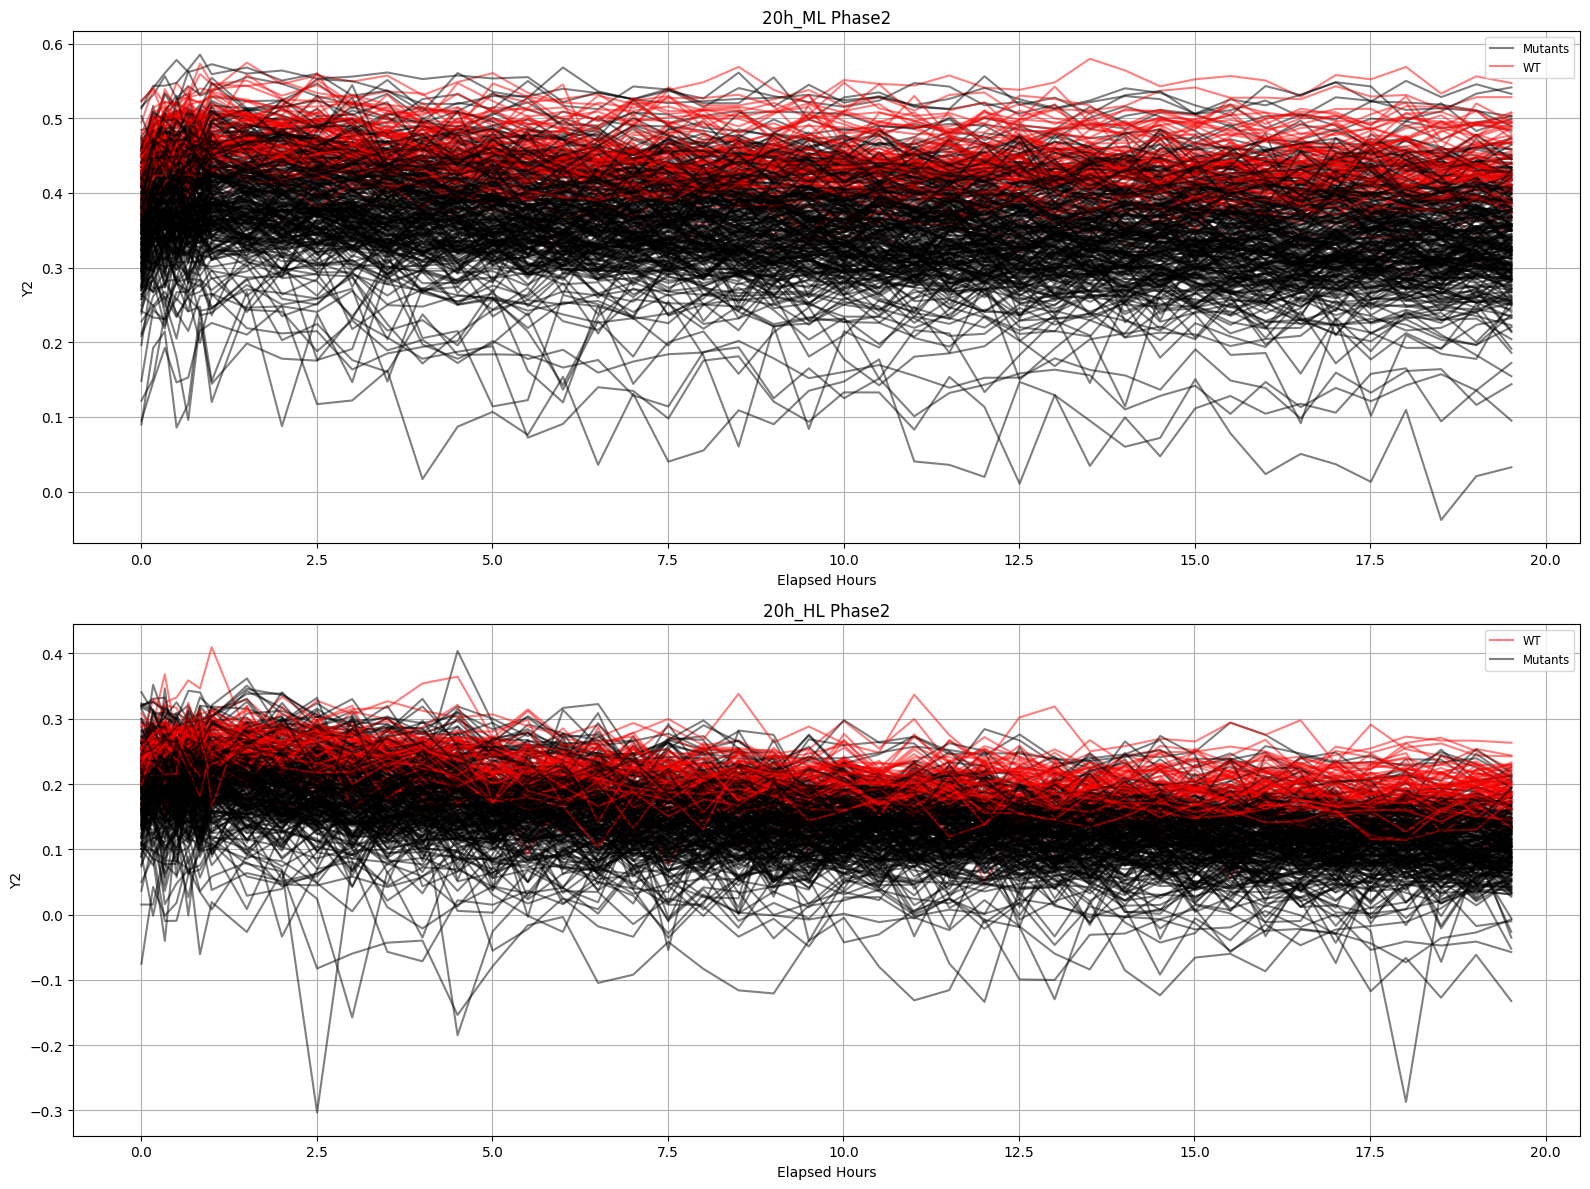

In [14]:
data = pd.concat((plate1,filtered_data))
data = filtered_data
data = data[data['plate'].astype(str).str.startswith('3')]
#data = data[data['mutant_ID']!='WT']
#data = data[data['mutant_ID']=='LMJ.RY0402.058045']
y2_columns = [col for col in data.columns if col.startswith('y2_') and col.split('_')[-1].isdigit() and 'std' not in col]
time_columns = [col for col in data.columns if col.startswith('measurement_time_')]
for col in time_columns:
    data[col] = pd.to_datetime(data[col],format='mixed')
elapsed_hours = data[time_columns].apply(lambda row: (row - row.min()).dt.total_seconds() / 3600, axis=1)

# for normalised data
elapsed_hours = [col for col in data.columns if col.startswith('elapsed_hours_')]
elapsed_hours = data[elapsed_hours]

# for raw slopes
# elapsed_hours.columns = [f'elapsed_hours_{i}' for i in range(len(elapsed_hours.columns))]
# data = pd.concat([data, elapsed_hours], axis=1)
plates = data['plate'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(plates)))  # Utilise une palette de couleurs avec suffisamment de couleurs
plate_colors = {plate: color for plate, color in zip(plates, colors)}
light_regimes = ['20h_ML','20h_HL']
fig, axes = plt.subplots(2, figsize=(16, 12))  
axes = axes.flatten()
for i, light in enumerate(light_regimes):
    c=0
    w=0
    ax = axes[i] 
    data_light = data[(data['light_regime'] == light)]
    plotted_plates = set()  # Pour suivre les `plates` déjà ajoutés à la légende

    for plate in data_light['plate'].unique():
        data_plate = data_light[(data_light['plate'] == plate)]
        for _, row in data_plate.iterrows():
            y2_values = row[y2_columns].values
            time_values = row[elapsed_hours.columns].astype(float).values

            valid_indices = ~np.isnan(time_values)
            time_values = time_values[valid_indices]
            y2_values = y2_values[:len(time_values)]  
            time_values = time_values[:len(y2_values)]
            
            if row['mutant_ID']!='WT':
                if w==0:
                    ax.plot(time_values, y2_values, alpha=0.5, label='Mutants', color='black')
                    w+=1   # Marquer le `plate` comme tracé

                else:
                    ax.plot(time_values, y2_values, alpha=0.5, color='black') 
            else:
                # Ajouter le label uniquement si le `plate` n'a pas encore été tracé
                if c==0:
                    ax.plot(time_values, y2_values, alpha=0.5, label='WT', color='red')
                    c+=1  # Marquer le `plate` comme tracé
                else:
                    ax.plot(time_values, y2_values, alpha=0.5, color='red')    #axes[i].set_xlim(0, 5)
    ax.set_title(f'{light} Phase2')
    ax.set_xlabel('Elapsed Hours')
    ax.set_ylabel('Y2')
    ax.grid(True)
    ax.legend(fontsize='small', loc='upper right')
for j in range(len(light_regimes), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()